In [9]:
import pandas as pd                 # Manejo de Dataframes
import matplotlib.pyplot as plt     # Gráficos
from PIL import Image, ImageOps     # Gráficos de Imágenes
import numpy as np                  # Números en general

# Librerías para definir el modelo de IA
from keras.models import Model
from keras.layers import Conv1D, Dense, Flatten, Input, Add, Dropout, ReLU, BatchNormalization

# Librearías para definir el entrenamiento de la IA
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, History

from keras.optimizers import Adam
import tensorflow as tf

# Librerías para Separación de Datos
from sklearn.model_selection import train_test_split

# Variables

In [10]:
# Path absoluto a direcciones de informacion
path_ds = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\merged\dataset_corr_w_inf.parquet"

# Distancia máxima antes de considerarse infinito
MAX_DIST = 650

# Variables de entrenamiento de la IA
callbacks = [EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=False
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6
        ),
        ModelCheckpoint(
            filepath="mejor_modelo.keras",
            monitor="val_loss",
            save_best_only=True
        )
]

epocs = 150
batch_size = 16

test_split = .1
val_split = .15     # con respecto al trainval, no al total 

# Funciones

### Funciones de métricas

Creadas para poder comparar y visualizar resultados

In [11]:
def plot_history(history: History):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    #["dist_custom_mae"]
    #["dist_loss"]
    #["learning_rate"]
    #["loss"]
    #["val_dist_custom_mae"]
    #["val_dist_loss"]
    #["val_loss"]
    #["val_wall_accuracy"]
    #["wall_accuracy"]
    #["wall_loss"]

    # LOSS TOTAL
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title("Loss total")
    axes[0].set_xlabel("Épocas")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # DISTANCIA
    axes[1].plot(history.history["dist_custom_mae"], label="train")
    axes[1].plot(history.history["val_dist_custom_mae"], label="val")
    axes[1].set_title("MAE distancia")
    axes[1].set_xlabel("Épocas")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(True)

    # DETECCION
    axes[2].plot(history.history["wall_accuracy"], label="train")
    axes[2].plot(history.history["val_wall_accuracy"], label="val")
    axes[2].set_title("Accuracy detección")
    axes[2].set_xlabel("Épocas")
    axes[2].set_ylabel("Accuracy")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()

    return fig, axes

def custom_mse(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    if y_pred.shape.rank == 3:
        y_pred = tf.squeeze(y_pred, axis=-1)

    mid = y_true.shape[1] // 2

    true_dist = y_true[:, :mid]
    wall_mask = y_true[:, mid:]

    error = tf.square(true_dist - y_pred)
    error = error * wall_mask

    return tf.reduce_sum(error) / (tf.reduce_sum(wall_mask) + 1e-8)

def custom_mae(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    if y_pred.shape.rank == 3:
        y_pred = tf.squeeze(y_pred, axis=-1)

    mid = y_true.shape[1] // 2

    true_dist = y_true[:, :mid]
    wall_mask = y_true[:, mid:]

    error = tf.abs(true_dist - y_pred)
    error = error * wall_mask

    return tf.reduce_sum(error) / (tf.reduce_sum(wall_mask) + 1e-8)


def mae(y_true, y_pred):
    """Mean Absolute Error global para arrays (N, L)."""
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    """Mean Squared Error global."""
    return np.mean((y_true - y_pred)**2)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error robusto.    Ignora valores muy pequeños."""
    eps = 1e-3
    mask = np.abs(y_true) > eps
    if np.sum(mask) == 0:
        return np.nan
    return np.mean( np.abs( (y_true[mask] - y_pred[mask]) / y_true[mask] ) ) * 100

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def metrics(y_dist_true, y_dist_pred, y_wall_true, y_wall_pred):
    """Retorna todas las métricas en un diccionario.    Las distancias ya deben estar filtradas"""

    MAE = mae(y_dist_true, y_dist_pred)
    MSE = mse(y_dist_true, y_dist_pred)
    RMSE = np.sqrt(MSE)
    MAPE = mape(y_dist_true, y_dist_pred)
    ACC = accuracy(y_wall_true, y_wall_pred)

    return {
        "MAE": MAE,
        "MSE": MSE,
        "RMSE": RMSE,
        "MAPE(%)": MAPE,
        "Accuracy": ACC,
    }

### Funciones del Modelo

Funciones para definir el modelo de IA a realizar y entrenar.

In [12]:
def init_model(seq_len=61, cant_inputs=2) -> Model:
    inp = Input(shape=(seq_len, cant_inputs))

    x = resnet_block(inp, filters=32, kernel_size=5)   # Bloque 1
    x = resnet_block(x, filters=64, kernel_size=3)     # Bloque 2
    x = resnet_block(x, filters=64, kernel_size=3, dilatation=2)     # Bloque 3

    dist_out = Conv1D(filters=1, kernel_size=1, activation="linear", name="dist")(x)
    wall_out = Conv1D(filters=1, kernel_size=1, activation="sigmoid", name="wall")(x)

    model = Model(
        inputs=inp, 
        outputs={
            'dist':dist_out, 
            'wall':wall_out,
            },
        )
    
    model.compile(
        optimizer=Adam(1e-3),
        loss={
            'dist': custom_mse,
            'wall': 'binary_crossentropy',
        },
        metrics={
            'dist': [custom_mae],
            'wall': ['accuracy'],
        },
        loss_weights={
            'dist': 1.0,
            'wall': 1.5,
        }
    )

    return model

def resnet_block(x, filters, kernel_size, dilatation=1):
    shortcut = x

    # Conv 1
    x = Conv1D(filters, kernel_size, padding="same", dilation_rate=dilatation, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv 2
    x = Conv1D(filters, kernel_size, padding="same", dilation_rate=dilatation, use_bias=False)(x)
    x = BatchNormalization()(x)

    # Proyección del shortcut si cambian los canales
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Suma residual + activación final
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x


def filter_distances(x, mask):
    x = np.array(x)
    mask = np.array(mask)
    return x[mask.astype(bool)]


### Funciones del Dataframe

Funciones para manipular el Dataframe. Imprimir cierto valor, obtener sus valores, limpiarlo, etc.

In [13]:
def get_data(df: pd.DataFrame, max_distance) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    X = []
    Y_dist = []
    Y_wall = []
    angles = np.linspace(0, 180, 61) / 180.0

    for _, row in df.iterrows():
        us = row['ultrasonico']        
        ir = row['infrarrojo']         
        real = row['distancias_mapa']  

        detect = (real <= max_distance).astype(np.float32)

        #real = np.clip(real, 0, max_distance)
        #real = real #/ max_distance                  # Real value normalized to MAX_DISTANCE

        # Entrada (61, 3)
        entrada = np.column_stack([us, ir, angles])

        X.append(entrada)
        Y_dist.append(real)
        Y_wall.append(detect)

    X = np.array(X, dtype=np.float32)
    Y_dist = np.array(Y_dist, dtype=np.float32)
    Y_wall = np.array(Y_wall, dtype=np.float32)

    return (X, Y_dist, Y_wall)

def clean_dataframe(df) -> pd.DataFrame:
    """
    Limpia filas inválidas del dataset.

    Conserva únicamente filas donde:
    - angulo existe
    - ultrasonico existe
    - infrarrojo existe
    - distancias_mapa existe
    - todos tienen la misma longitud
    """

    required_cols = ["angulo", "ultrasonico", "infrarrojo", "distancias_mapa"]
    valid_types = (list, np.ndarray)

    df.drop(columns='imagen_path', inplace=True, errors='ignore')

    def valid_row(row):
        for col in required_cols:
            if not isinstance(row[col], valid_types):
                return False
        n = len(row["angulo"])

        return (
            len(row["ultrasonico"]) == n and
            len(row["infrarrojo"]) == n and
            len(row["distancias_mapa"]) == n
        )

    df = df[df.apply(valid_row, axis=1)].copy()
    return df.reset_index()



### Funciones de gráficos
plot polar con límite para graficar cómodamente

In [14]:
def plot_polar(angles_deg, values, title=None, ax:plt.Axes=None, 
               threshold=None, threshold_color="red", **plot_kwargs):
    if ax is None:
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection="polar")
    else:
        fig = ax.figure

    angles_rad = np.deg2rad(angles_deg)
    ax.plot(angles_rad, values, **plot_kwargs)

    # Limite
    if threshold is not None:
        full_circle = np.linspace(0, 2*np.pi, 400)
        r_max = max(max(values), threshold * 1.2)
        ax.fill_between(full_circle, threshold, r_max, color=threshold_color, alpha=0.2)
        ax.plot(full_circle, np.full_like(full_circle, threshold), color=threshold_color, linestyle="--", linewidth=1.5)
        ax.set_ylim(0, threshold * 1.1)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    if title:
        ax.set_title(title)

    ax.grid(True)
    return fig, ax

def plot_all_scans(df: pd.DataFrame, idx, mode="side", threshold = 500):
    """
    mode="side": 3 subplots polares, lado a lado
    mode="overlay": 3 curvas superpuestas en 1 solo polar
    """

    row = df.iloc[idx]
    ang = row["angulo"]
    us  = row["ultrasonico"]
    ir  = row["infrarrojo"]
    ang_map = row.get("angulos_mapa")
    dist_map = row.get("distancias_mapa")
    
    scan_id = row.get("id", idx)

    # --- MODO SUBPLOTS LATERALES ---
    if mode == "side":
        fig = plt.figure(figsize=(18,6))
        
        # Ultrasonido
        ax1 = fig.add_subplot(131, projection="polar")
        plot_polar(ang, us, title="Ultrasonido", ax=ax1, threshold=threshold)

        # Infrarrojo
        ax2 = fig.add_subplot(132, projection="polar")
        plot_polar(ang, ir, title="Infrarrojo", ax=ax2, threshold=threshold)

        # Imagen procesada
        ax3 = fig.add_subplot(133, projection="polar")
        plot_polar(ang_map, dist_map, title="Foto procesada", ax=ax3, threshold=threshold)

        fig.suptitle(f"Medición ID {scan_id}", fontsize=14)
        plt.tight_layout()
        plt.show()
        return fig

    # --- MODO SUPERPUESTO ---
    elif mode == "overlay":
        fig = plt.figure(figsize=(7,7))
        ax = fig.add_subplot(111, projection="polar")

        plot_polar(ang, us,  ax=ax, label="Ultrasonido", threshold=threshold)
        plot_polar(ang, ir,  ax=ax, label="Infrarrojo", threshold=threshold)
        plot_polar(ang_map, dist_map, ax=ax, label="Distancia mapa", threshold=threshold)

        ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
        ax.set_title(f"Medición ID {scan_id} — Comparación")

        plt.show()
        return fig

    else:
        raise ValueError('mode debe ser "side" o "overlay"')
    

# Carga del Dataset

Se carga la carpeta con los .csv y se limpia el dataframe para poder ser utilizado luego.

In [15]:
# Cargo el dataframe
df = pd.read_parquet(path_ds)

# Limpio el dataframe
df = clean_dataframe(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   index            389 non-null    int64 
 1   id               389 non-null    int64 
 2   fecha            389 non-null    str   
 3   angulo           389 non-null    object
 4   ultrasonico      389 non-null    object
 5   infrarrojo       389 non-null    object
 6   kalman           389 non-null    object
 7   angulos_mapa     389 non-null    object
 8   distancias_mapa  389 non-null    object
 9   image_path       389 non-null    str   
dtypes: int64(2), object(6), str(2)
memory usage: 72.3+ KB


In [16]:
df

,index,id,fecha,angulo,ultrasonico,infrarrojo,kalman,angulos_mapa,distancias_mapa,image_path
0,0,1,2025-12-06T13:05:24.470944,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[197.0, 192.0, 197.0, 197.0, 208.0, 212.0, 283...","[191.93, 191.93, 189.93, 184.93, 192.93, 201.9...","[185.29212264150942, 188.86541630148992, 190.8...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[178.0, 180.5, 184.0, 187.5, 192.5, 198.0, 204...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
1,1,2,2025-12-06T13:05:52.590537,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[197.0, 196.0, 197.0, 197.0, 429.0, 246.0, 278...","[192.93, 192.93, 192.93, 191.93, 193.93, 201.9...","[185.76853773584904, 190.42545135845748, 192.3...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[189.5, 192.5, 196.5, 200.5, 205.5, 211.5, 218...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
2,2,3,2025-12-06T13:06:21.379133,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[191.0, 191.0, 191.0, 191.0, 192.0, 197.0, 198...","[197.93, 197.93, 197.93, 197.93, 197.93, 197.9...","[185.29212264150942, 190.20415425065733, 192.0...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[206.5, 207.0, 207.0, 208.0, 209.5, 212.0, 215...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
3,3,4,2025-12-06T13:06:39.521396,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[191.0, 191.0, 191.0, 196.0, 197.0, 197.0, 198...","[188.93, 194.93, 197.93, 194.93, 194.93, 195.9...","[181.0043867924528, 187.40923751095528, 190.39...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[210.0, 210.0, 210.5, 212.0, 213.5, 215.5, 218...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
4,4,5,2025-12-06T13:07:02.273272,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[196.0, 191.0, 191.0, 191.0, 192.0, 192.0, 197...","[197.93, 197.93, 197.93, 197.93, 197.93, 198.9...","[187.67419811320752, 191.31063978965818, 192.6...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[213.0, 212.5, 213.0, 214.0, 216.0, 218.5, 221...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
...,...,...,...,...,...,...,...,...,...,...
384,401,40,2026-05-11T12:53:48.810517,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[271.0, 271.0, 275.0, 275.0, 281.0, 285.0, 300...","[255.93, 266.93, 255.93, 257.93, 271.93, 276.9...","[251.03740566037732, 260.6375460122699, 262.68...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[316.0, 1000.0, 314.5, 317.0, 320.0, 323.0, 32...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
385,402,41,2026-05-11T12:54:19.562383,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[275.0, 275.0, 275.0, 275.0, 276.0, 285.0, 308...","[266.93, 262.93, 266.93, 268.93, 270.93, 263.9...","[258.1836320754717, 263.95700262927255, 266.92...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[315.5, 313.5, 314.0, 316.0, 318.5, 322.5, 327...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
386,403,42,2026-05-11T12:54:38.046261,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[271.0, 275.0, 275.0, 275.0, 280.0, 280.0, 295...","[255.93, 262.93, 259.93, 258.93, 261.93, 274.9...","[251.03740566037732, 260.6375460122699, 263.53...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[310.0, 1000.0, 308.0, 310.0, 313.0, 316.5, 32...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...
387,406,45,2026-05-11T12:55:26.678547,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[271.0, 270.0, 275.0, 275.0, 290.0, 290.0, 290...","[262.93, 249.93, 249.93, 235.93, 251.93, 269.9...","[254.3723113207547, 257.3671691498685, 259.527...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[319.5, 317.5, 318.0, 320.5, 323.0, 327.5, 332...",E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Da...


Chequeo del dataset

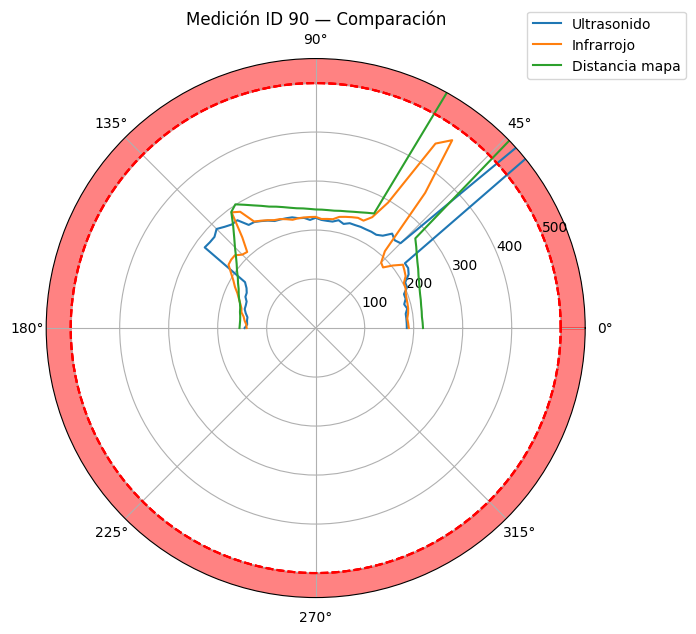

In [17]:
idx = 83
plot_all_scans(df, idx, mode='overlay');

# Entrenamiento de IA

Se separan los datos en splits de train, test y valid

In [18]:
X, Y_dist, Y_wall = get_data(df, MAX_DIST)
y_dist_combined = np.concatenate([Y_dist, Y_wall], axis=1 )

X_train, X_test, y_dist_train, y_dist_test, y_wall_train, y_wall_test = train_test_split( 
	X, y_dist_combined, Y_wall, 
	test_size=test_split, 
	shuffle=True, 
	random_state=21
	)

## Entrenamiento final

In [19]:
model_final = init_model(seq_len=X.shape[1], cant_inputs=X.shape[2])
model_final.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 61, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 61, 32)    │        480 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 61, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 61, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 61, 32)    │      5,120 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 61, 32)    │         96 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 61, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 61, 32)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 61, 64)    │      6,144 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 61, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 61, 64)    │     12,288 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 61, 64)    │      2,048 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 61, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 61, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 61, 64)    │     12,288 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 52,546 (205.26 KB)

 Trainable params: 51,714 (202.01 KB)

 Non-trainable params: 832 (3.25 KB)

In [20]:
history = model_final.fit(
    X_train,
    {
        "dist": y_dist_train,
        "wall": y_wall_train
    },
    validation_split=val_split,
    epochs=epocs,
    batch_size=batch_size,
    callbacks=callbacks,
)

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 160ms/step - dist_custom_mae: 258.1856 - dist_loss: 73128.9297 - loss: 73229.6875 - wall_accuracy: 0.2428 - wall_loss: 1.2281 - val_dist_custom_mae: 283.5390 - val_dist_loss: 89439.8906 - val_loss: 89079.4219 - val_wall_accuracy: 0.2527 - val_wall_loss: 1.4271 - learning_rate: 0.0010
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - dist_custom_mae: 255.1669 - dist_loss: 71864.2109 - loss: 71520.8516 - wall_accuracy: 0.4032 - wall_loss: 0.9962 - val_dist_custom_mae: 275.1102 - val_dist_loss: 84369.3594 - val_loss: 83977.3750 - val_wall_accuracy: 0.3464 - val_wall_loss: 0.7905 - learning_rate: 0.0010
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - dist_custom_mae: 251.8324 - dist_loss: 69860.7500 - loss: 70014.3359 - wall_accuracy: 0.8039 - wall_loss: 0.5141 - val_dist_custom_mae: 269.8181 - val_dist_loss: 81375.1328 - val_loss: 80961.5547 - val_wall_accuracy: 0.7813 - val_wall_loss: 0.4731 - learning_rate: 0.0010
Epoch 4/150
19/19 ━━

# Verificacion de resultados


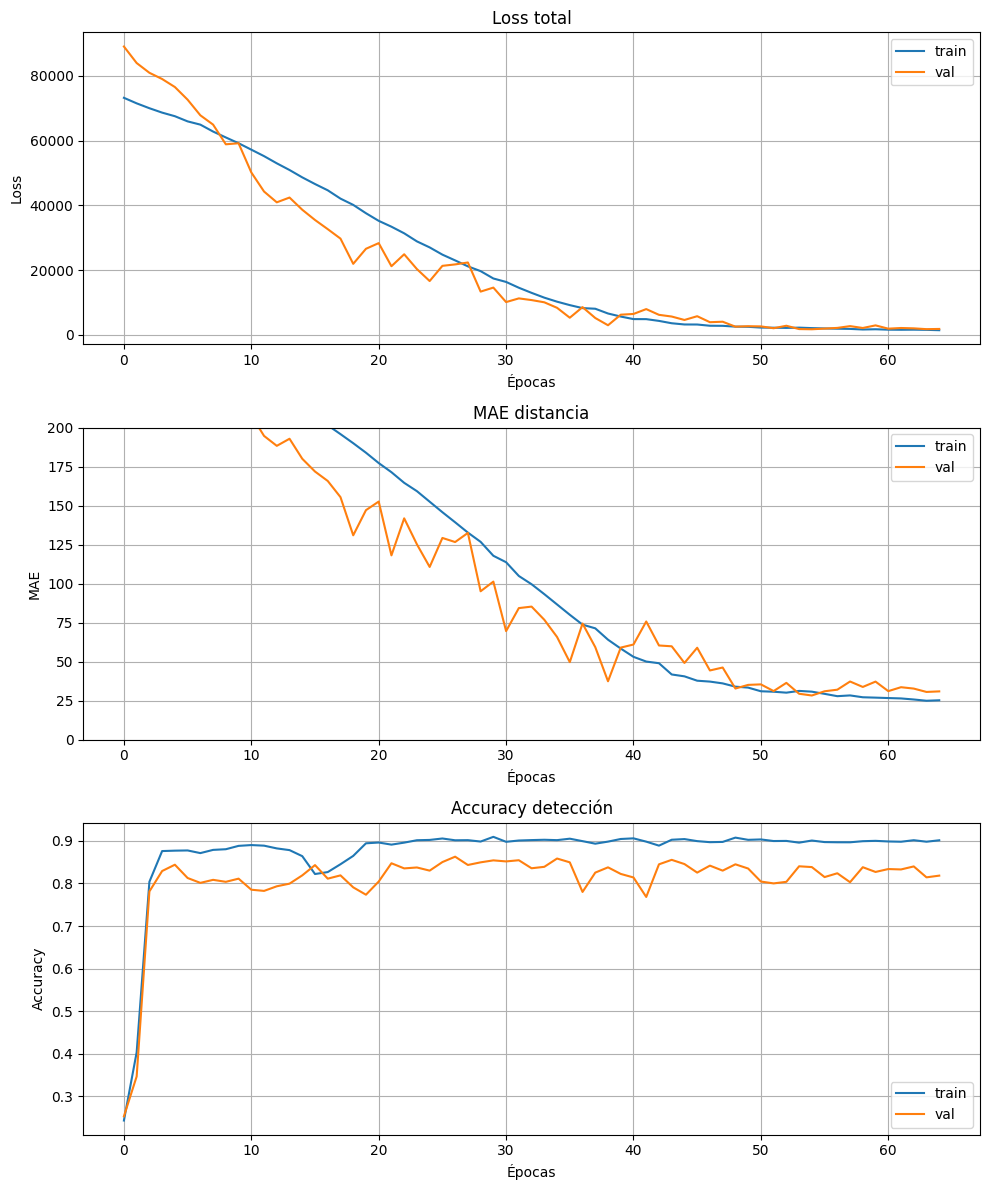

In [21]:
fig, ax = plot_history(history)
#ax[0].set_ylim(0, 200)
ax[1].set_ylim(0, 200)
plt.show()

In [23]:
#["dist_custom_mae"]
#["dist_loss"]
#["learning_rate"]
#["loss"]
#["val_dist_custom_mae"]
#["val_dist_loss"]
#["val_loss"]
#["val_wall_accuracy"]
#["wall_accuracy"]
#["wall_loss"]

results = model_final.evaluate(
	X_test,
    {"dist": y_dist_test, "wall": y_wall_test},
    verbose=0,
    return_dict=True
)

print("\n" + "="*48)
print("         RESULTADOS FINALES")
print("="*48)

print(f"{'Métrica':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-"*48)

print(
    f"{'Loss':<20} "
    f"{min(history.history['loss']):>8.4g} "
    f"{min(history.history['val_loss']):>8.4g} "
    f"{results['loss']:>8.4g}"
)

print(
    f"{'Dist MAE':<20} "
    f"{min(history.history['dist_custom_mae']):>8.4g} "
    f"{min(history.history['val_dist_custom_mae']):>8.4g} "
    f"{results['dist_custom_mae']:>8.4g}"
)

print(
    f"{'Detect Acc':<20} "
    f"{max(history.history['wall_accuracy']):>8.4g} "
    f"{max(history.history['val_wall_accuracy']):>8.4g} "
    f"{results['wall_accuracy']:>8.4g}"
)

print("="*48)


         RESULTADOS FINALES
Métrica                 Train      Val     Test
------------------------------------------------
Loss                     1428     1717     1289
Dist MAE                24.87    28.24    26.42
Detect Acc             0.9096    0.863   0.8432


In [24]:
X, Y_dist, Y_wall = get_data(df, MAX_DIST)
kalman = np.stack(df['kalman'].to_list())

res = model_final.predict(X)
pred_dist = res['dist'].squeeze(-1)
pred_wall = res['wall'].squeeze(-1)  # Asegurarse de que pred_wall tenga forma (N, L)
pred_dist = np.where(pred_wall > 0.5, pred_dist, -1).astype(np.float32)

Y_dist_filtered = filter_distances(Y_dist, Y_wall)
Y_dist_kalman_filtered = filter_distances(kalman, Y_wall)
pred_dist_filtered = filter_distances(pred_dist, Y_wall)

kalman_metrics = metrics(Y_dist_filtered, Y_dist_kalman_filtered, Y_wall, pred_wall)
ia_metrics = metrics(Y_dist_filtered, pred_dist_filtered, Y_wall, pred_wall)

print("\n" + "=" * 60)
print(f"{'Método':<12} {'MAE':>10} {'MSE':>10} {'RMSE':>10} {'MAPE (%)':>12}")
print("-" * 60)

print(
    f"{'Kalman':<12} "
    f"{kalman_metrics['MAE']:>10.4f} "
    f"{kalman_metrics['MSE']:>10.4f} "
    f"{kalman_metrics['RMSE']:>10.4f} "
    f"{kalman_metrics['MAPE(%)']:>12.4f}"
)

print(
    f"{'IA':<12} "
    f"{ia_metrics['MAE']:>10.4f} "
    f"{ia_metrics['MSE']:>10.4f} "
    f"{ia_metrics['RMSE']:>10.4f} "
    f"{ia_metrics['MAPE(%)']:>12.4f}"
)

print("=" * 60)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step

Método              MAE        MSE       RMSE     MAPE (%)
------------------------------------------------------------
Kalman          51.1902 17526.9270   132.3893      18.5030
IA              28.6825  2121.2886    46.0574      10.8882


E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\20.jpg


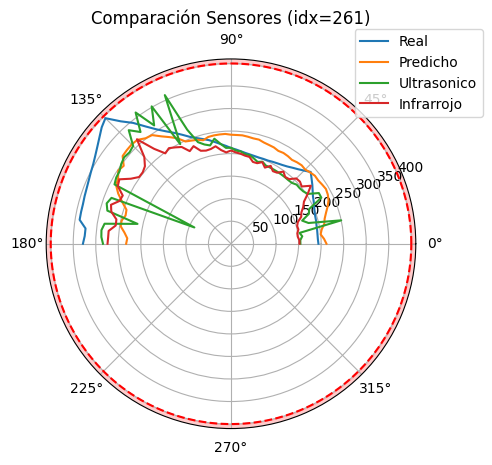

In [15]:
idx = np.random.randint(len(X))
us = X[idx][:, 0]
ir = X[idx][:, 1]
img_path = df['image_path']

print(img_path[idx])
angulos = np.linspace(0, 180, len(X[idx]))
mask = Y_wall[idx] > 0.5

fig = plt.figure()
ax = fig.add_subplot(111, projection="polar")

plot_polar(angulos[mask], Y_dist[idx][mask], threshold=400, ax=ax, label="Real")
plot_polar(angulos[mask], pred_dist[idx][mask], ax=ax, label="Predicho")
plot_polar(angulos[mask], us[mask], ax=ax, label="Ultrasonico")
plot_polar(angulos[mask], ir[mask], ax=ax, label="Infrarrojo")
#plot_polar(angulos, 200*mask, ax=ax, label="valido")

[ymin, _] = ax.get_ylim()
ax.set_ylim(ymin, 410)

ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax.set_title(f"Comparación Sensores (idx={idx})")
plt.show()

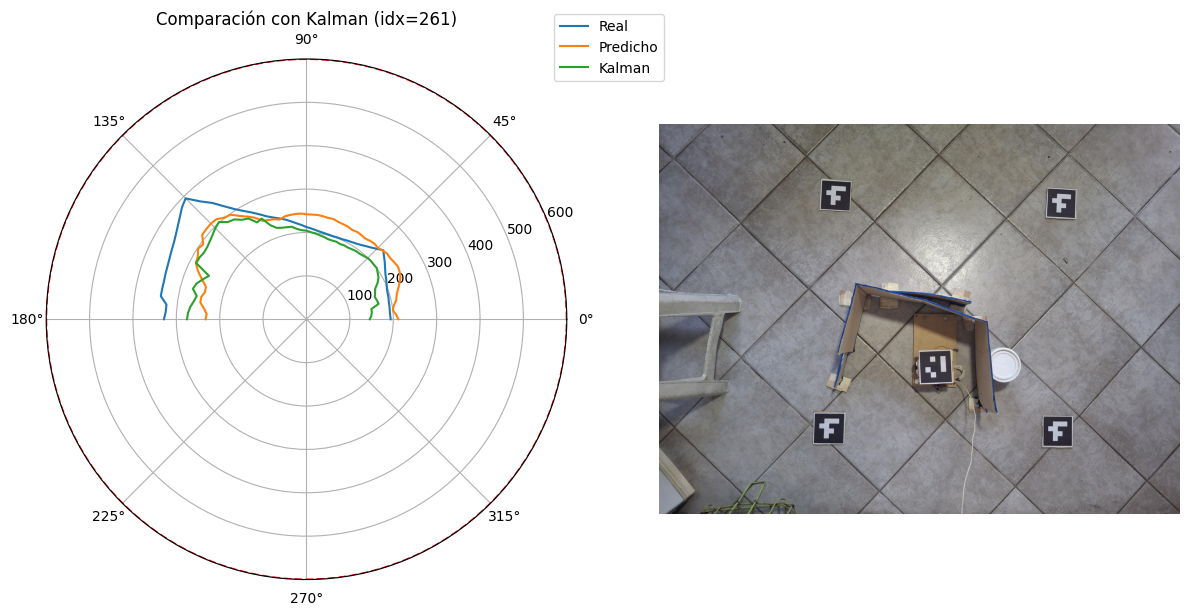

In [16]:
fig = plt.figure(figsize=(12,10))

# Prediccion
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
plot_polar(angulos[mask], Y_dist[idx][mask], threshold=600, ax=ax_polar, label="Real")
plot_polar(angulos[mask], pred_dist[idx][mask], ax=ax_polar, label="Predicho")
plot_polar(angulos[mask], kalman[idx][mask], ax=ax_polar, label="Kalman")

[ymin, _] = ax_polar.get_ylim()
ax_polar.set_ylim(ymin, 600)
ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación con Kalman (idx={idx})")

# Imagen
ax_img = fig.add_subplot(1, 2, 2)
img = Image.open(img_path[idx])
img = ImageOps.exif_transpose(img)   # Corrige la rotación automáticamente
img = np.array(img)

ax_img.imshow(img)
ax_img.axis("off")


plt.tight_layout()
plt.show()


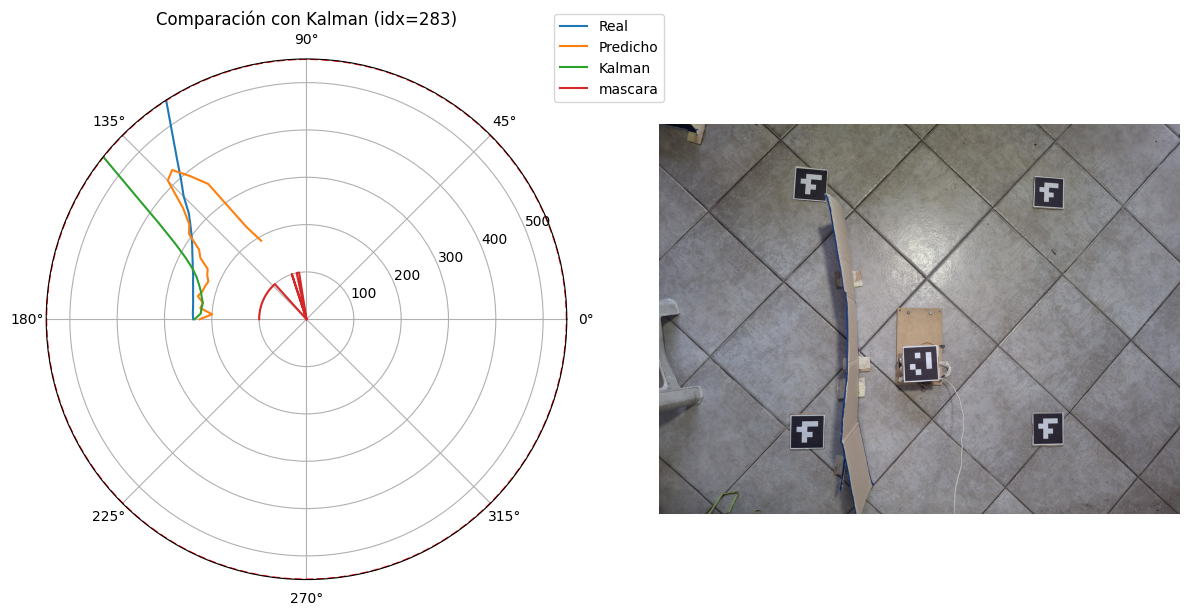

Path a Imagen:
E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\42.jpg


In [26]:
idx = 283 #np.random.randint(len(X))   
mask = Y_wall[idx] == 1
res = model_final.predict(X, verbose=0)
pred_dist = res['dist'].squeeze(-1)
pred_wall = res['wall'].squeeze(-1)  # Asegurarse de que pred_wall tenga forma (N, L)
pred_wall = (pred_wall > 0.5).astype(np.float32)    # Pasaje float -> binario

img_path = df.loc[idx, "image_path"]

angulos = np.linspace(0, 180, len(Y_dist[idx]))


## Prueba random de test
fig = plt.figure(figsize=(12,10))

# Prediccion
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
plot_polar(angulos, Y_dist[idx] , threshold=550, ax=ax_polar, label="Real")
plot_polar(angulos[mask], pred_dist[idx][mask], ax=ax_polar, label="Predicho")
plot_polar(angulos[mask], kalman[idx][mask], ax=ax_polar, label="Kalman")
plot_polar(angulos, 100*pred_wall[idx], ax=ax_polar, label="mascara")

[ymin, _] = ax_polar.get_ylim()
ax_polar.set_ylim(ymin, 550)
ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación con Kalman (idx={idx})")

# Imagen
ax_img = fig.add_subplot(1, 2, 2)
img = Image.open(img_path)
img = ImageOps.exif_transpose(img)   # Corrige la rotación automáticamente
img = np.array(img)

ax_img.imshow(img)
ax_img.axis("off")


plt.tight_layout()
plt.show()

print("Path a Imagen:")
print(img_path)

## IDX 180
## IDX 50
## IDX 283